# Momepy roads 

This notebook uses momepy to calculate geometrical features of the streets, such as width and openess.

## Import libraries

In [2]:
import momepy as mm
import geopandas as gpd
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Import noise segments

In [3]:
edges = gpd.read_file("../../layers/bcn_osmnx_edges.gpkg")
print(edges.crs)  #CRS = Coordinate Reference System
print(edges.shape)
print(edges.columns.tolist())
print("Number of street segments:", len(edges))

EPSG:25831
(16541, 21)
['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'access', 'junction', 'ref', 'width', 'est_width', 'tunnel', 'bridge', 'service', 'segment_id', 'geometry']
Number of street segments: 16541


## Import and project buildings

In [4]:
place_name = "Barcelona, Spain"
tags = {'building': True}

print("Downloading buildings from OSM...")
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)
    
# Project buildings to the same CRS as edges
buildings = buildings.to_crs(edges.crs)



In [5]:
buildings.info()
buildings.head(10)

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 68873 entries, ('node', np.int64(71643580)) to ('way', np.int64(1516922113))
Columns: 554 entries, geometry to viewpoint
dtypes: geometry(1), str(553)
memory usage: 292.0+ MB


geometry     addr:housename  \
element id                                                              
node    71643580    POINT (428712.527 4587416.309)  Centre Collserola   
        1401592110  POINT (431251.198 4580463.572)                NaN   
        1404685243  POINT (431423.252 4580429.234)                NaN   
        1437642713  POINT (431631.576 4581734.811)                NaN   
        1711341255   POINT (427809.19 4580772.409)                NaN   
        2085649393  POINT (432454.266 4582360.687)                NaN   
        2187296750  POINT (432773.341 4583883.113)                NaN   
        2194567285  POINT (431541.753 4584308.989)                NaN   
        2336827547   POINT (431506.388 4588878.65)                NaN   
        2629932730  POINT (427808.339 4582134.239)                NaN   

                   addr:housenumber addr:postcode  \
element id                                          
node    71643580            159-169         08035   
        1401592110              NaN         08039   
        1404685243              NaN         08039   
        1437642713               14         08003   
        1711341255              NaN         08014   
        2085649393               20           NaN   
        2187296750              NaN           NaN   
        2194567285              NaN           NaN   
        2336827547            11-15         08042   
        2629932730              292         08029   

                                    addr:street     building  \
element id                                                     
node    71643580    Passeig de la Vall d'Hebron  residential   
        1401592110   Avinguda Moll de Barcelona          yes   
        1404685243   Avinguda Moll de Barcelona          yes   
        1437642713             Plaçeta Montcada          yes   
        1711341255                          NaN       public   
        2085649393                Doctor Trueta    warehouse   
        2187296750                          NaN  residential   
        2194567285                          NaN  residential   
        2336827547            Carrer Portlligat        civic   
        2629932730      Travessera de les Corts          yes   

                                                  name   wikidata  addr:city  \
element id                                                                     
node    71643580            Centre de Vida Independent  Q87761569        NaN   
        1401592110                                 NaN        NaN  Barcelona   
        1404685243                                 NaN        NaN  Barcelona   
        1437642713  Plataforma d'Entitats de la Ribera        NaN        NaN   
        1711341255      Centre Cívic Cotxeres de Sants        NaN  Barcelona   
        2085649393                     Almacén Policia        NaN        NaN   
        2187296750                        Optim Center        NaN        NaN   
        2194567285                             vivagym        NaN        NaN   
        2336827547        Ateneu Popular de Nou Barris  Q21478774        NaN   
        2629932730                        NH Les Corts        NaN  Barcelona   

                             amenity  ... official_name:hu  \
element id                            ...                    
node    71643580                 NaN  ...              NaN   
        1401592110  parking_entrance  ...              NaN   
        1404685243  parking_entrance  ...              NaN   
        1437642713               NaN  ...              NaN   
        1711341255  community_centre  ...              NaN   
        2085649393               NaN  ...              NaN   
        2187296750               NaN  ...              NaN   
        2194567285               NaN  ...              NaN   
        2336827547           theatre  ...              NaN   
        2629932730               NaN  ...              NaN   

                   wheelchair:description:de amenity:

In [6]:
# First, ensure both columns are numeric
buildings['height'] = pd.to_numeric(buildings.get('height'), errors='coerce')
buildings['building:levels'] = pd.to_numeric(buildings.get('building:levels'), errors='coerce')

# Compute derived height: use 'height' if present, else 'building:levels' * 3, else fallback to 3
buildings['height_derived'] = buildings['height'].fillna(buildings['building:levels'] * 3).fillna(3)
# Set maximum height to 50 meters to avoid outliers
buildings['height_derived'] = buildings['height_derived'].clip(upper=50)

buildings['height_derived'].info()


<class 'pandas.Series'>
MultiIndex: 68873 entries, ('node', np.int64(71643580)) to ('way', np.int64(1516922113))
Series name: height_derived
Non-Null Count  Dtype  
--------------  -----  
68873 non-null  float64
dtypes: float64(1)
memory usage: 1.5+ MB


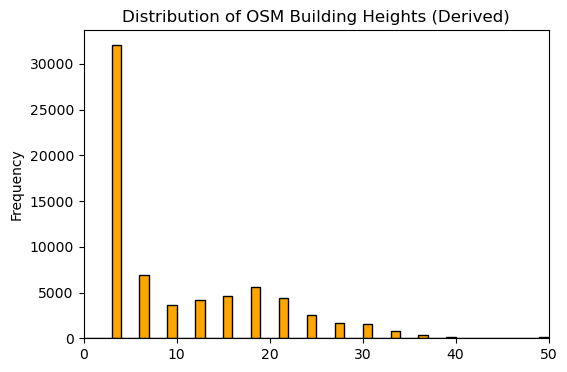

In [7]:
buildings['height_derived'].plot(kind='hist', bins=50, figsize=(6, 4), color='orange', edgecolor='black')
plt.title('Distribution of OSM Building Heights (Derived)')
plt.xlim(0, 50)
plt.show()

## Create Momepy street profile

In [8]:
profile = mm.street_profile(edges, buildings, height = buildings['height_derived'])
profile.head()

,width,openness,width_deviation,height,height_deviation,hw_ratio
0,43.025602,0.750000,5.740353,4.500000,2.121320,0.104589
1,26.114886,0.363095,5.540738,12.700935,7.896996,0.486348
2,15.135908,0.750000,4.211717,11.500000,12.020815,0.759783
3,18.154330,0.666667,0.210299,19.000000,1.414214,1.046582
4,20.158620,0.666667,1.308920,19.000000,1.414214,0.942525


In [9]:
edges[profile.columns] = profile
edges[profile.columns].head()

,width,openness,width_deviation,height,height_deviation,hw_ratio
0,43.025602,0.750000,5.740353,4.500000,2.121320,0.104589
1,26.114886,0.363095,5.540738,12.700935,7.896996,0.486348
2,15.135908,0.750000,4.211717,11.500000,12.020815,0.759783
3,18.154330,0.666667,0.210299,19.000000,1.414214,1.046582
4,20.158620,0.666667,1.308920,19.000000,1.414214,0.942525


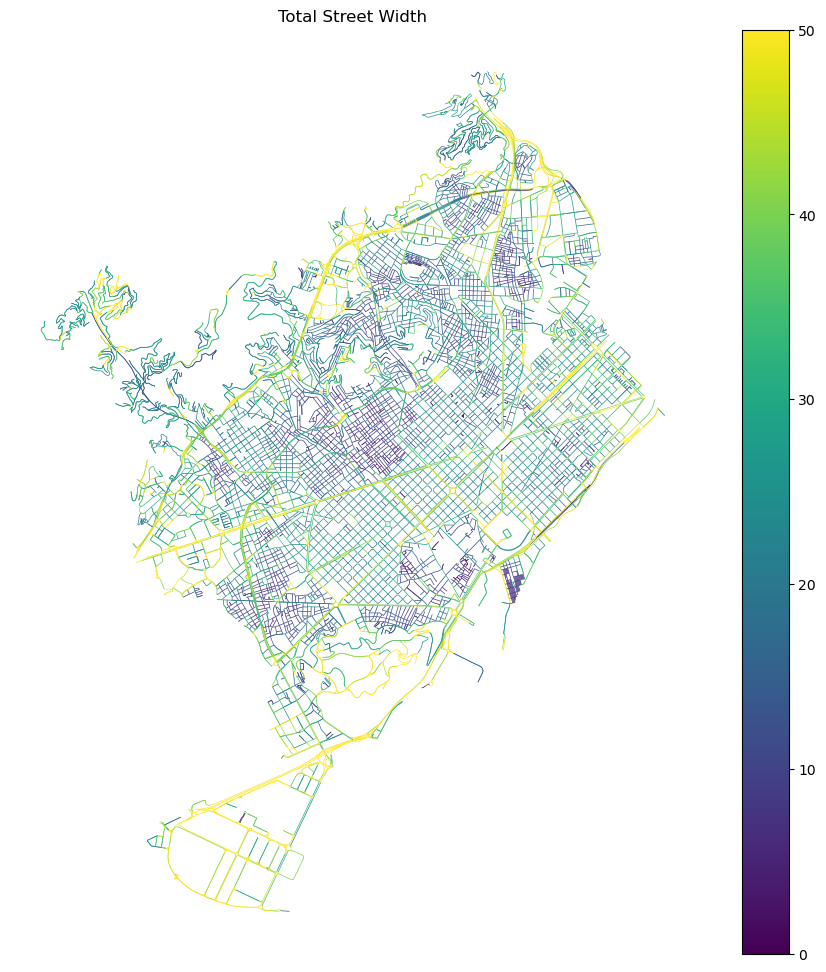

In [10]:
ax = edges.plot(cmap="viridis", column='width', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Total Street Width')
ax.set_axis_off()

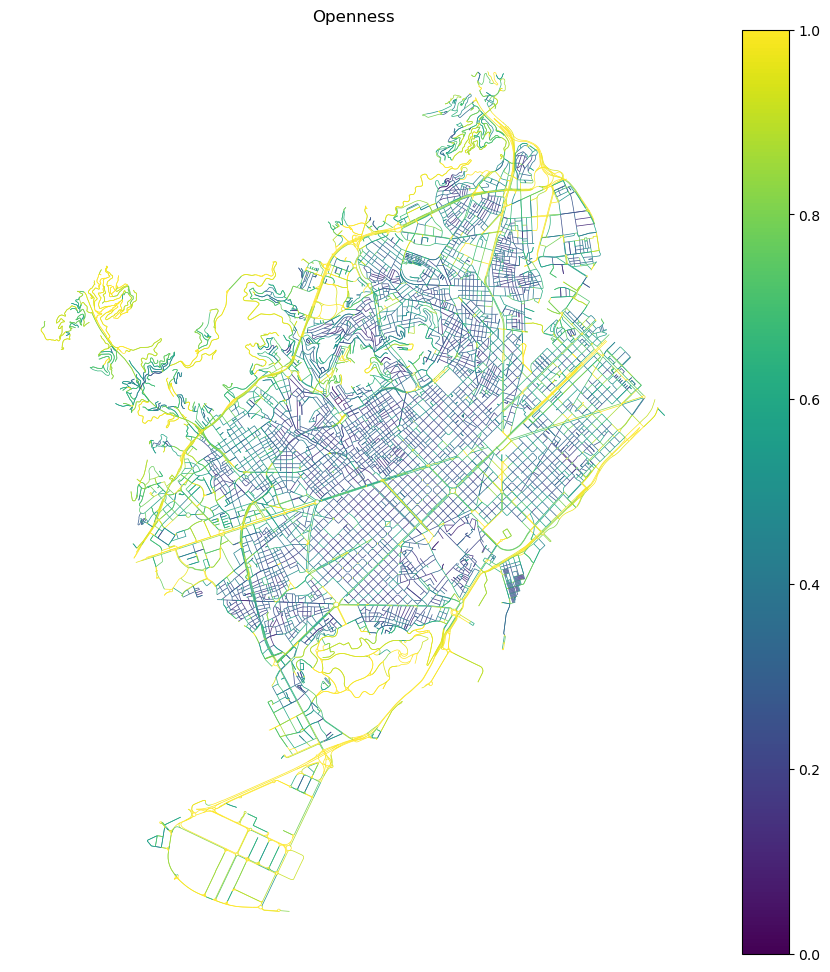

In [11]:
ax = edges.plot(cmap="viridis", column='openness', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Openness')
ax.set_axis_off()

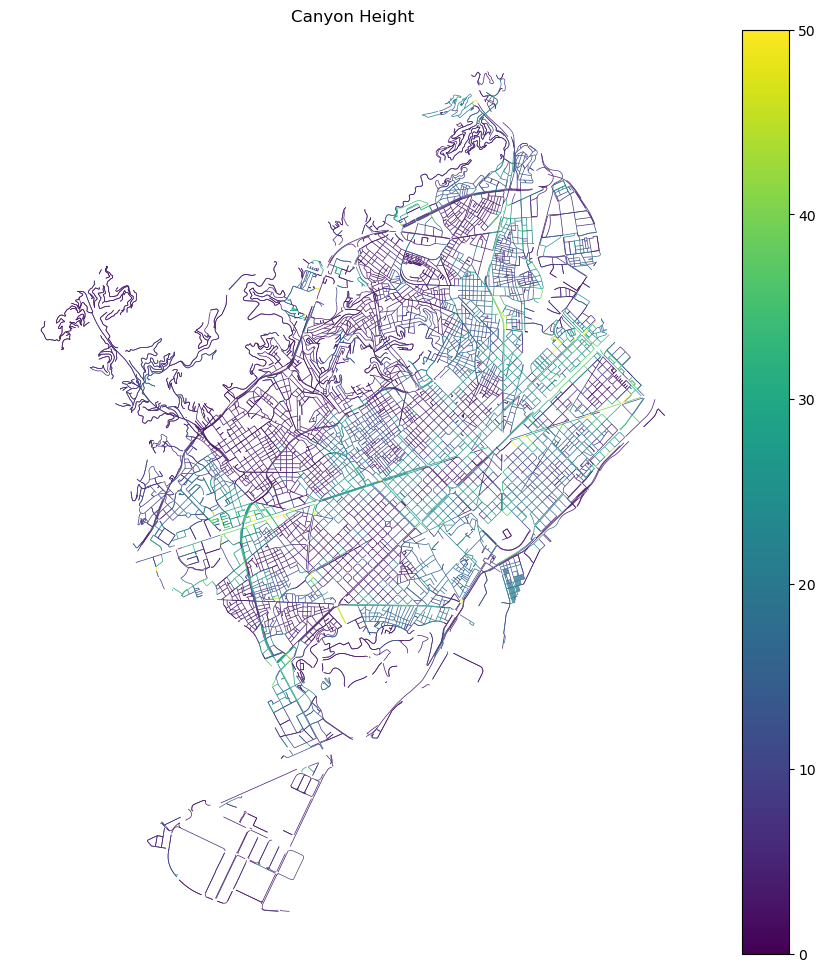

In [12]:
ax = edges.plot(cmap="viridis", column='height', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Canyon Height')
ax.set_axis_off()

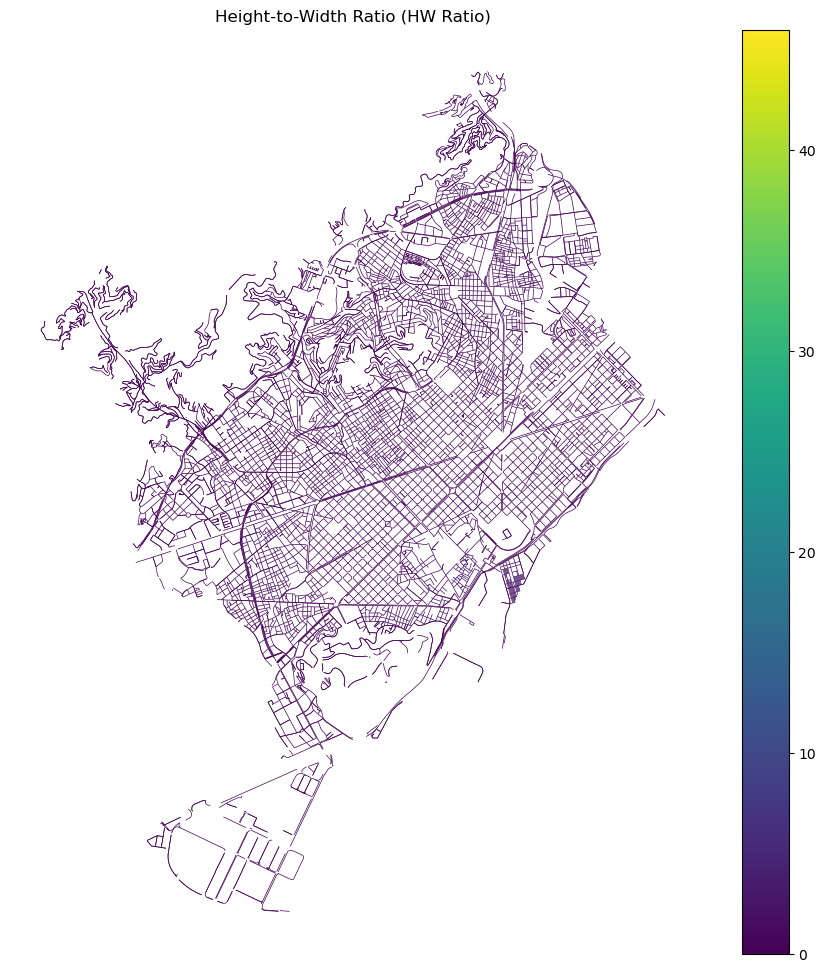

In [13]:
ax = edges.plot(cmap="viridis", column='hw_ratio', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Height-to-Width Ratio (HW Ratio)')
ax.set_axis_off()


# Centrality

## Betweenness Centrality

In [14]:
primal = mm.gdf_to_nx(edges, approach="primal")

Careful, takes long

In [15]:
betweenness = mm.betweenness_centrality(
    primal, name="betweenness_metric_e", mode="edges", weight="mm_len"
)

In [16]:
primal_gdf_betw = mm.nx_to_gdf(betweenness, points=False)
primal_gdf_betw.head()

,u,v,__key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,service,segment_id,geometry,openness,width_deviation,height,height_deviation,hw_ratio,mm_len,betweenness_metric_e
0,21638845,885308258,0,554707785,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,21638845_885308258_0,"LINESTRING (432071.186 4580160.408, 432067.928...",0.750000,5.740353,4.500000,2.121320,0.104589,28.292092,0.000896
1,21638845,13175411896,0,"[1433594636, 4079500, 543357596, 902517725, 42...",residential,"['3', '4']",30,Passeig de Joan de Borbó,False,True,...,NaN,21638845_13175411896_0,"LINESTRING (432071.186 4580160.408, 432066.515...",0.363095,5.540738,12.700935,7.896996,0.486348,615.655095,0.002015
2,13175411896,21638845,0,"[4079500, 1433594636, 543357596, 902517725, 42...",residential,"['3', '4']",30,Passeig de Joan de Borbó,False,False,...,NaN,13175411896_21638845_0,"LINESTRING (432176.044 4580757.599, 432174.921...",0.339286,5.726241,12.648649,7.865516,0.475500,615.655095,0.002015
3,885308314,21638845,0,554707788,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,885308314_21638845_0,"LINESTRING (432087.076 4580133.49, 432071.186 ...",1.000000,NaN,NaN,NaN,NaN,31.257819,0.000896
4,885308258,885308166,0,"[74975048, 214435425]",residential,"['1', '2']",30,Passeig de Joan de Borbó,True,False,...,NaN,885308258_885308166_0,"LINESTRING (432067.928 4580132.304, 432066.177...",0.562500,0.594311,3.428571,1.089410,0.089877,119.292946,0.000672


Text(0.5, 1.0, 'Betweenness Centrality (Edge Based)')

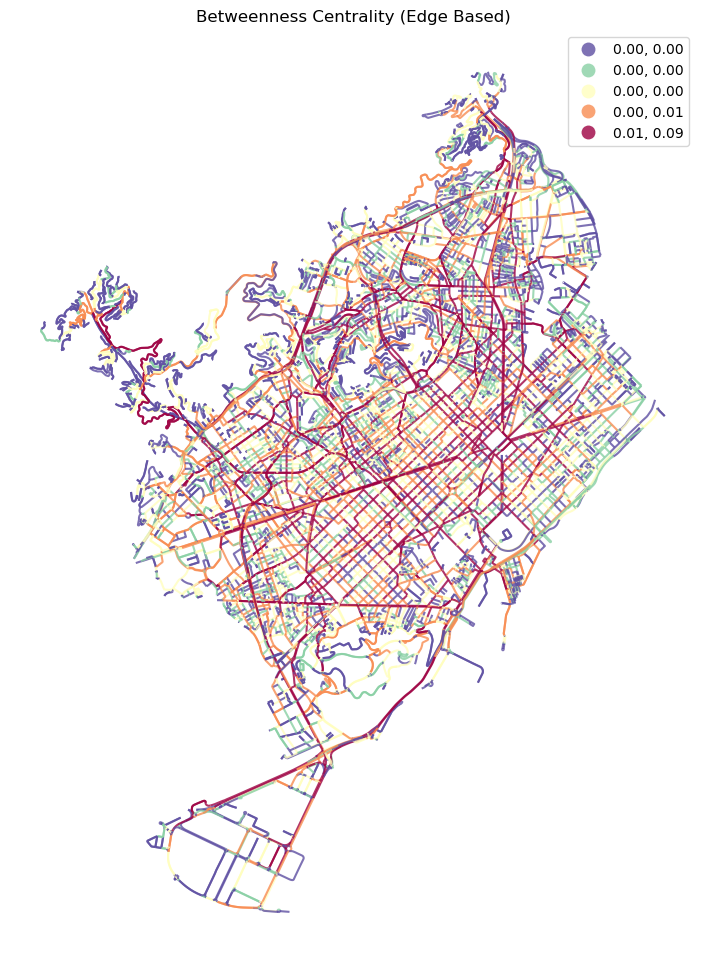

In [17]:
ax = primal_gdf_betw.plot(
    column="betweenness_metric_e",
    cmap="Spectral_r",
    scheme="quantiles",
    alpha=0.8,
    legend=True,
    figsize=(12, 12)
)
ax.set_axis_off()
ax.set_title("Betweenness Centrality (Edge Based)")

## Global Closenness Centrality

Careful, takes long

In [18]:
closeness = mm.closeness_centrality(
    primal, name="closeness_global", weight="mm_len"
)

In [19]:
nodes = mm.nx_to_gdf(closeness, lines=False)
nodes.head()

,x,y,closeness_global,nodeID,geometry
0,432071.185960,4.580160e+06,0.000147,0,POINT (432071.186 4580160.408)
1,432067.928377,4.580132e+06,0.000146,1,POINT (432067.928 4580132.304)
2,432176.043537,4.580758e+06,0.000162,2,POINT (432176.044 4580757.599)
3,432319.661133,4.580900e+06,0.000161,3,POINT (432319.661 4580899.827)
4,432304.736209,4.580896e+06,0.000161,4,POINT (432304.736 4580895.659)


Text(0.5, 1.0, 'Closenness Global (Node Based)')

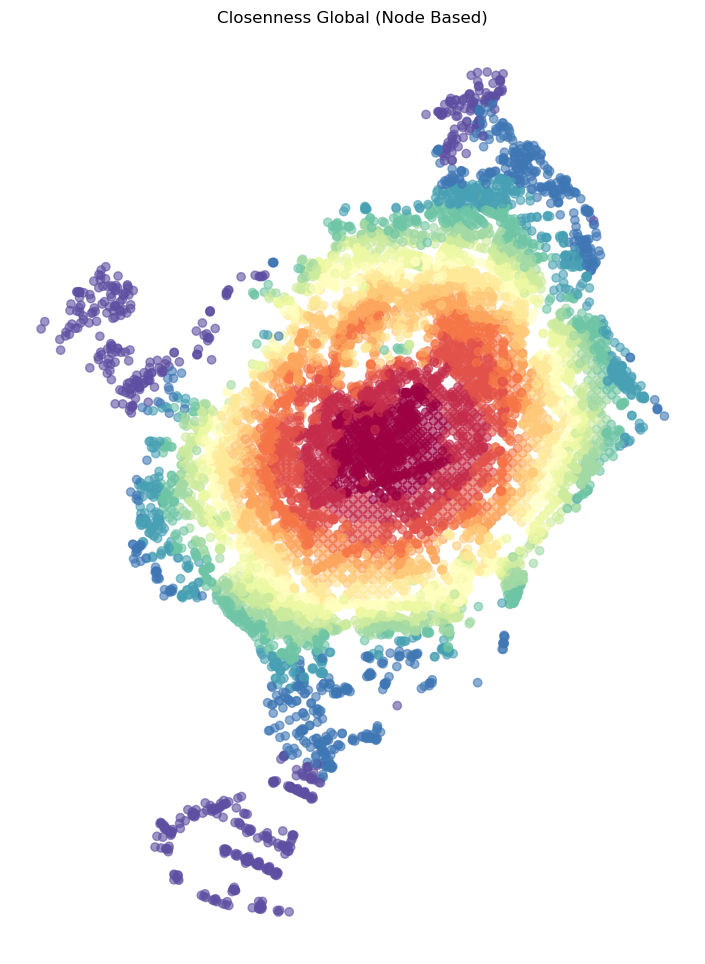

In [20]:
ax = nodes.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
ax.set_title("Closenness Global (Node Based)")

In [21]:
mm.mean_nodes(closeness, "closeness_global")

In [22]:
primal_gdf_clos = mm.nx_to_gdf(closeness, points=False)
primal_gdf_clos.head()

,u,v,__key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,service,segment_id,geometry,openness,width_deviation,height,height_deviation,hw_ratio,mm_len,closeness_global
0,21638845,885308258,0,554707785,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,21638845_885308258_0,"LINESTRING (432071.186 4580160.408, 432067.928...",0.750000,5.740353,4.500000,2.121320,0.104589,28.292092,0.000147
1,21638845,13175411896,0,"[1433594636, 4079500, 543357596, 902517725, 42...",residential,"['3', '4']",30,Passeig de Joan de Borbó,False,True,...,NaN,21638845_13175411896_0,"LINESTRING (432071.186 4580160.408, 432066.515...",0.363095,5.540738,12.700935,7.896996,0.486348,615.655095,0.000154
2,13175411896,21638845,0,"[4079500, 1433594636, 543357596, 902517725, 42...",residential,"['3', '4']",30,Passeig de Joan de Borbó,False,False,...,NaN,13175411896_21638845_0,"LINESTRING (432176.044 4580757.599, 432174.921...",0.339286,5.726241,12.648649,7.865516,0.475500,615.655095,0.000154
3,885308314,21638845,0,554707788,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,885308314_21638845_0,"LINESTRING (432087.076 4580133.49, 432071.186 ...",1.000000,NaN,NaN,NaN,NaN,31.257819,0.000147
4,885308258,885308166,0,"[74975048, 214435425]",residential,"['1', '2']",30,Passeig de Joan de Borbó,True,False,...,NaN,885308258_885308166_0,"LINESTRING (432067.928 4580132.304, 432066.177...",0.562500,0.594311,3.428571,1.089410,0.089877,119.292946,0.000145


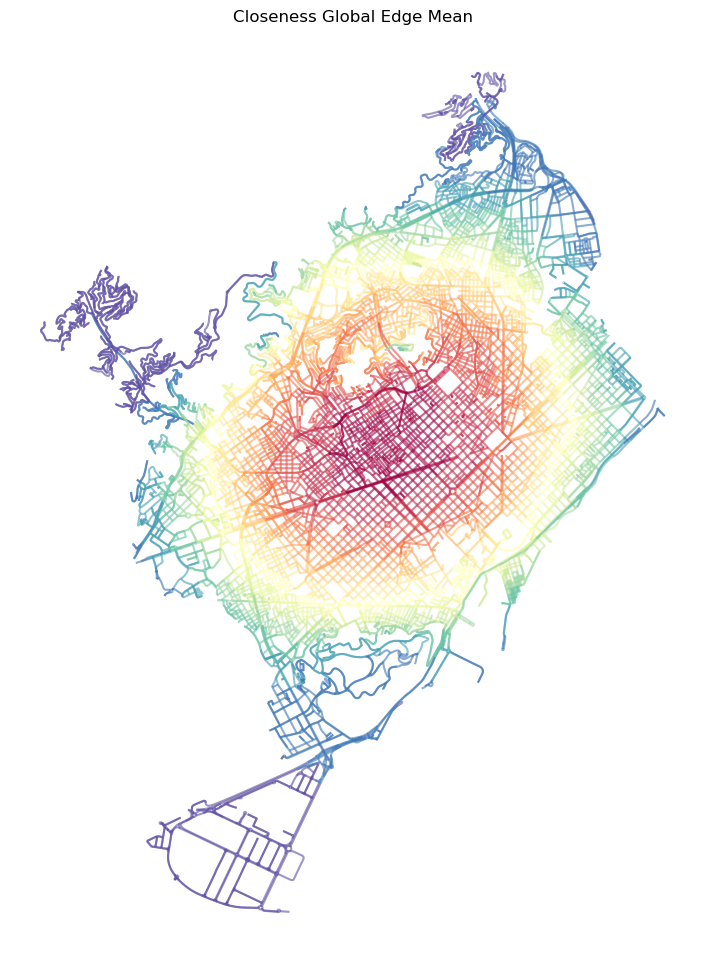

In [23]:

ax = primal_gdf_clos.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
_ = ax.set_title("Closeness Global Edge Mean")

In [24]:
# Merge on 'segment_id' (or the appropriate key)
primal_gdf = primal_gdf_betw.merge(
    primal_gdf_clos[['segment_id', 'closeness_global']],
    on='segment_id',
    how='left'
)
primal_gdf.head()

,u,v,__key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,segment_id,geometry,openness,width_deviation,height,height_deviation,hw_ratio,mm_len,betweenness_metric_e,closeness_global
0,21638845,885308258,0,554707785,residential,2,30,Passeig de Joan de Borbó,True,False,...,21638845_885308258_0,"LINESTRING (432071.186 4580160.408, 432067.928...",0.750000,5.740353,4.500000,2.121320,0.104589,28.292092,0.000896,0.000147
1,21638845,13175411896,0,"[1433594636, 4079500, 543357596, 902517725, 42...",residential,"['3', '4']",30,Passeig de Joan de Borbó,False,True,...,21638845_13175411896_0,"LINESTRING (432071.186 4580160.408, 432066.515...",0.363095,5.540738,12.700935,7.896996,0.486348,615.655095,0.002015,0.000154
2,13175411896,21638845,0,"[4079500, 1433594636, 543357596, 902517725, 42...",residential,"['3', '4']",30,Passeig de Joan de Borbó,False,False,...,13175411896_21638845_0,"LINESTRING (432176.044 4580757.599, 432174.921...",0.339286,5.726241,12.648649,7.865516,0.475500,615.655095,0.002015,0.000154
3,885308314,21638845,0,554707788,residential,2,30,Passeig de Joan de Borbó,True,False,...,885308314_21638845_0,"LINESTRING (432087.076 4580133.49, 432071.186 ...",1.000000,NaN,NaN,NaN,NaN,31.257819,0.000896,0.000147
4,885308258,885308166,0,"[74975048, 214435425]",residential,"['1', '2']",30,Passeig de Joan de Borbó,True,False,...,885308258_885308166_0,"LINESTRING (432067.928 4580132.304, 432066.177...",0.562500,0.594311,3.428571,1.089410,0.089877,119.292946,0.000672,0.000145


In [25]:
dataset = pd.DataFrame({
    "road_id": primal_gdf['segment_id'],
    "road_width": primal_gdf['width'],
    "canyon_height": primal_gdf['height'],
    "betweenness": primal_gdf['betweenness_metric_e'],
    "closeness": primal_gdf['closeness_global'],
}).fillna(0) #fillna(0) to replace any NaN values with 0

dataset.head()

,road_id,road_width,canyon_height,betweenness,closeness
0,21638845_885308258_0,43.025602,4.500000,0.000896,0.000147
1,21638845_13175411896_0,26.114886,12.700935,0.002015,0.000154
2,13175411896_21638845_0,26.600754,12.648649,0.002015,0.000154
3,885308314_21638845_0,50.000000,0.000000,0.000896,0.000147
4,885308258_885308166_0,38.147174,3.428571,0.000672,0.000145


## Export dataset to CSV

In [28]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
edges.to_csv(os.path.join(output_dir, "momepy_streets.csv"), index=False)
print("Exported momepy_streets.csv")

Exported momepy_streets.csv


TODO: using building height we could also calculate street canyon height and h/w ratio, which are relevant for noise propagation.